# Hierarchical Kaggle Output Quicklook

Notebook này chỉ đọc kết quả đã export trong `kaggle_output/` để xem nhanh metric, training curve, classification report, confusion matrix và ROC curve. Không train lại model.

In [15]:
# !pip install numpy
# !pip install matplotlib
# !pip install pandas

In [16]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

OUTPUT_DIR = Path('kaggle_output')
CONF_DIR = OUTPUT_DIR / 'confusion_matrices'

assert OUTPUT_DIR.exists(), f'Missing output folder: {OUTPUT_DIR.resolve()}'
assert CONF_DIR.exists(), f'Missing diagnostics folder: {CONF_DIR.resolve()}'

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.dpi'] = 120

print('Output folder:', OUTPUT_DIR.resolve())
print('Diagnostics folder:', CONF_DIR.resolve())

Output folder: D:\Download_D\ĐATN 20252\Notebook_DATN\kaggle_output
Diagnostics folder: D:\Download_D\ĐATN 20252\Notebook_DATN\kaggle_output\confusion_matrices


In [17]:
def read_csv(name, **kwargs):
    path = OUTPUT_DIR / name
    if not path.exists():
        print(f'Missing: {path}')
        return pd.DataFrame()
    return pd.read_csv(path, **kwargs)

epoch_df = read_csv('epoch_metrics.csv')
final_df = read_csv('final_metrics_summary.csv')
test_df = read_csv('test_metrics_summary.csv')

def resolve_output_path(value):
    if pd.isna(value) or value == '':
        return None
    p = Path(str(value))
    if p.exists():
        return p
    if 'confusion_matrices' in p.parts:
        return CONF_DIR / p.name
    return OUTPUT_DIR / p.name

def backfill_roc_auc_from_curve(test_metrics):
    if test_metrics.empty or 'roc_curve_csv' not in test_metrics.columns:
        return test_metrics
    test_metrics = test_metrics.copy()
    for col in ['roc_auc_macro_ovr', 'roc_auc_weighted_ovr', 'roc_auc_micro_ovr']:
        if col not in test_metrics.columns:
            test_metrics[col] = np.nan

    for idx, row in test_metrics.iterrows():
        roc_path = resolve_output_path(row.get('roc_curve_csv'))
        if roc_path is None or not roc_path.exists():
            continue
        roc_df = pd.read_csv(roc_path)
        if not {'class_name', 'auc'}.issubset(roc_df.columns):
            continue
        per_class_auc = roc_df.groupby('class_name')['auc'].max()
        if pd.isna(row.get('roc_auc_micro_ovr')) and 'micro_average' in per_class_auc.index:
            test_metrics.loc[idx, 'roc_auc_micro_ovr'] = per_class_auc.loc['micro_average']
        class_auc = per_class_auc.drop(labels=['micro_average'], errors='ignore')
        if pd.isna(row.get('roc_auc_macro_ovr')) and len(class_auc) > 0:
            test_metrics.loc[idx, 'roc_auc_macro_ovr'] = class_auc.mean()

        report_path = resolve_output_path(row.get('classification_report_csv'))
        if pd.isna(row.get('roc_auc_weighted_ovr')) and report_path is not None and report_path.exists():
            report_df = pd.read_csv(report_path, index_col=0)
            support = report_df['support'].drop(labels=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
            common = class_auc.index.intersection(support.index)
            if len(common) > 0 and support.loc[common].sum() > 0:
                test_metrics.loc[idx, 'roc_auc_weighted_ovr'] = np.average(
                    class_auc.loc[common], weights=support.loc[common]
                )
    return test_metrics

test_df = backfill_roc_auc_from_curve(test_df)

summary = pd.DataFrame([
    {'file': 'epoch_metrics.csv', 'rows': len(epoch_df), 'columns': len(epoch_df.columns)},
    {'file': 'final_metrics_summary.csv', 'rows': len(final_df), 'columns': len(final_df.columns)},
    {'file': 'test_metrics_summary.csv', 'rows': len(test_df), 'columns': len(test_df.columns)},
])
display(summary)

if not test_df.empty:
    display(Markdown('## Test Metrics Leaderboard'))
    metric_cols = [
        'model_name', 'num_samples', 'loss', 'accuracy', 'balanced_accuracy', 'mcc',
        'macro_precision', 'macro_recall', 'macro_f1',
        'weighted_precision', 'weighted_recall', 'weighted_f1',
        'roc_auc_macro_ovr', 'roc_auc_weighted_ovr', 'roc_auc_micro_ovr',
    ]
    metric_cols = [c for c in metric_cols if c in test_df.columns]
    display(test_df[metric_cols].sort_values('macro_f1', ascending=False).reset_index(drop=True))

if not final_df.empty:
    display(Markdown('## Final Validation Metrics'))
    display(final_df.sort_values('macro_f1', ascending=False).reset_index(drop=True))

,file,rows,columns
0,epoch_metrics.csv,245,15
1,final_metrics_summary.csv,9,11
2,test_metrics_summary.csv,9,21


## Test Metrics Leaderboard

,model_name,num_samples,loss,accuracy,balanced_accuracy,mcc,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,roc_auc_micro_ovr
0,SUB_XOI_EFFB2,177,0.340742,0.994350,0.988506,0.988960,0.997151,0.988506,0.992721,0.994399,0.994350,0.994313,0.999812,0.999630,0.999824
1,SUB_DAC_BIET_EFFB2,518,0.778845,0.945946,0.945024,0.942772,0.945997,0.945024,0.945077,0.946925,0.945946,0.946016,0.997301,0.997236,0.997054
2,SUB_BANH_EFFB2,3058,0.833952,0.944408,0.939380,0.941664,0.949448,0.939380,0.943646,0.944778,0.944408,0.944132,0.997020,0.996581,0.996722
3,SUB_COM_EFFB2,344,0.554168,0.956395,0.928323,0.936537,0.943022,0.928323,0.935385,0.955808,0.956395,0.955878,0.997277,0.997958,0.998221
4,SUB_GOI_CUON_EFFB2,399,0.546048,0.954887,0.930561,0.938840,0.931402,0.930561,0.930502,0.955076,0.954887,0.954714,0.993712,0.996467,0.996276
5,SUB_CANH_CHAO_EFFB2,611,0.651120,0.952537,0.923156,0.942090,0.924539,0.923156,0.921307,0.955468,0.952537,0.952586,0.997769,0.998701,0.998762
6,SUB_BUN_PHO_EFFB2,1742,0.810362,0.909300,0.918090,0.899393,0.917784,0.918090,0.916190,0.911295,0.909300,0.909201,0.994070,0.991488,0.993286
7,SUB_MON_KHO_NUONG_EFFB2,768,0.763589,0.932292,0.910344,0.924642,0.919003,0.910344,0.912973,0.935890,0.932292,0.932903,0.997691,0.997994,0.998279
8,GROUP_EFFB0,7384,0.660899,0.924160,0.901057,0.899578,0.924930,0.901057,0.912398,0.924517,0.924160,0.924045,0.993228,0.991114,0.993879


## Final Validation Metrics

,model_name,accuracy,loss,balanced_accuracy,mcc,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,SUB_XOI_EFFB2,0.988764,0.330003,0.986015,0.978222,0.987025,0.986015,0.986349,0.988934,0.988764,0.988760
1,SUB_COM_EFFB2,0.970674,0.510403,0.949007,0.957302,0.965109,0.949007,0.955747,0.971529,0.970674,0.970326
2,SUB_DAC_BIET_EFFB2,0.942748,0.758009,0.943069,0.939536,0.946507,0.943069,0.943351,0.946712,0.942748,0.943295
3,SUB_GOI_CUON_EFFB2,0.954887,0.564890,0.950997,0.939485,0.935364,0.950997,0.941224,0.957100,0.954887,0.954989
4,SUB_BANH_EFFB2,0.945264,0.835864,0.934058,0.942579,0.946272,0.934058,0.938851,0.945961,0.945264,0.944889
5,SUB_CANH_CHAO_EFFB2,0.944444,0.677271,0.918925,0.931998,0.928438,0.918925,0.923183,0.944800,0.944444,0.944358
6,SUB_MON_KHO_NUONG_EFFB2,0.933852,0.774085,0.919348,0.926381,0.926760,0.919348,0.921863,0.935329,0.933852,0.933743
7,SUB_BUN_PHO_EFFB2,0.899483,0.836111,0.911935,0.888493,0.918239,0.911935,0.914228,0.900193,0.899483,0.898807
8,GROUP_EFFB0,0.924827,0.668317,0.903950,0.900502,0.921335,0.903950,0.912171,0.924975,0.924827,0.924663


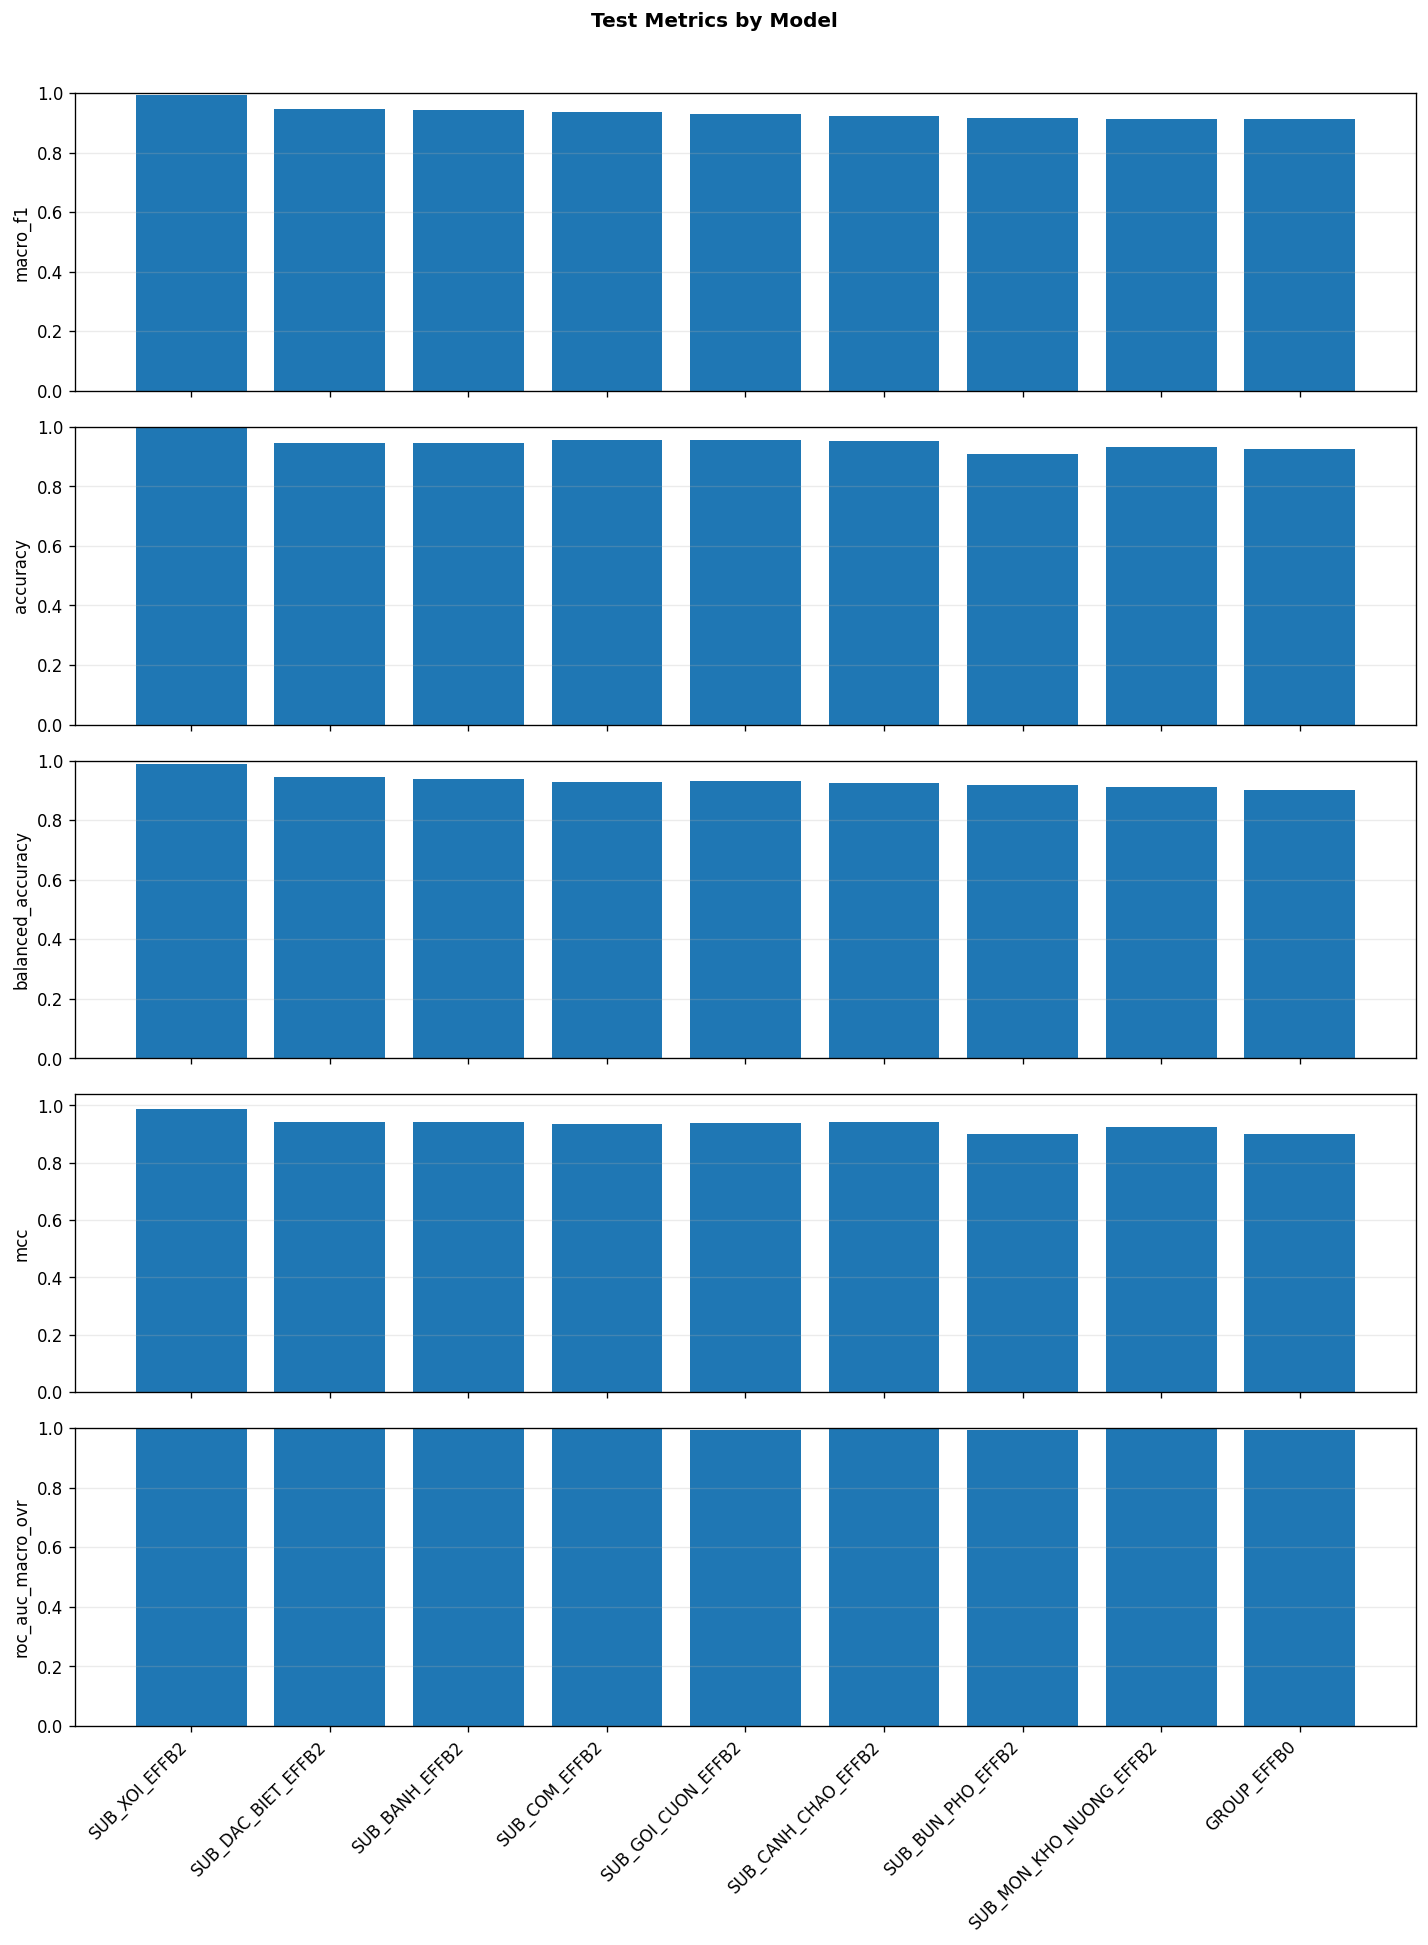

In [18]:
def plot_metric_bars(df, metrics, title):
    if df.empty:
        print('No data to plot')
        return
    metrics = [m for m in metrics if m in df.columns]
    if not metrics:
        print('No metric columns found')
        return
    plot_df = df.copy().sort_values(metrics[0], ascending=False)
    n = len(metrics)
    fig, axes = plt.subplots(n, 1, figsize=(12, max(3.5, 3.2 * n)), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        ax.bar(plot_df['model_name'], plot_df[metric])
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1 if metric != 'mcc' else max(1, plot_df[metric].max() * 1.05))
        ax.grid(axis='y', alpha=0.25)
        for tick in ax.get_xticklabels():
            tick.set_rotation(45)
            tick.set_ha('right')
    fig.suptitle(title, y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_metric_bars(
    test_df,
    ['macro_f1', 'accuracy', 'balanced_accuracy', 'mcc', 'roc_auc_macro_ovr'],
    'Test Metrics by Model'
)

## Training Curves

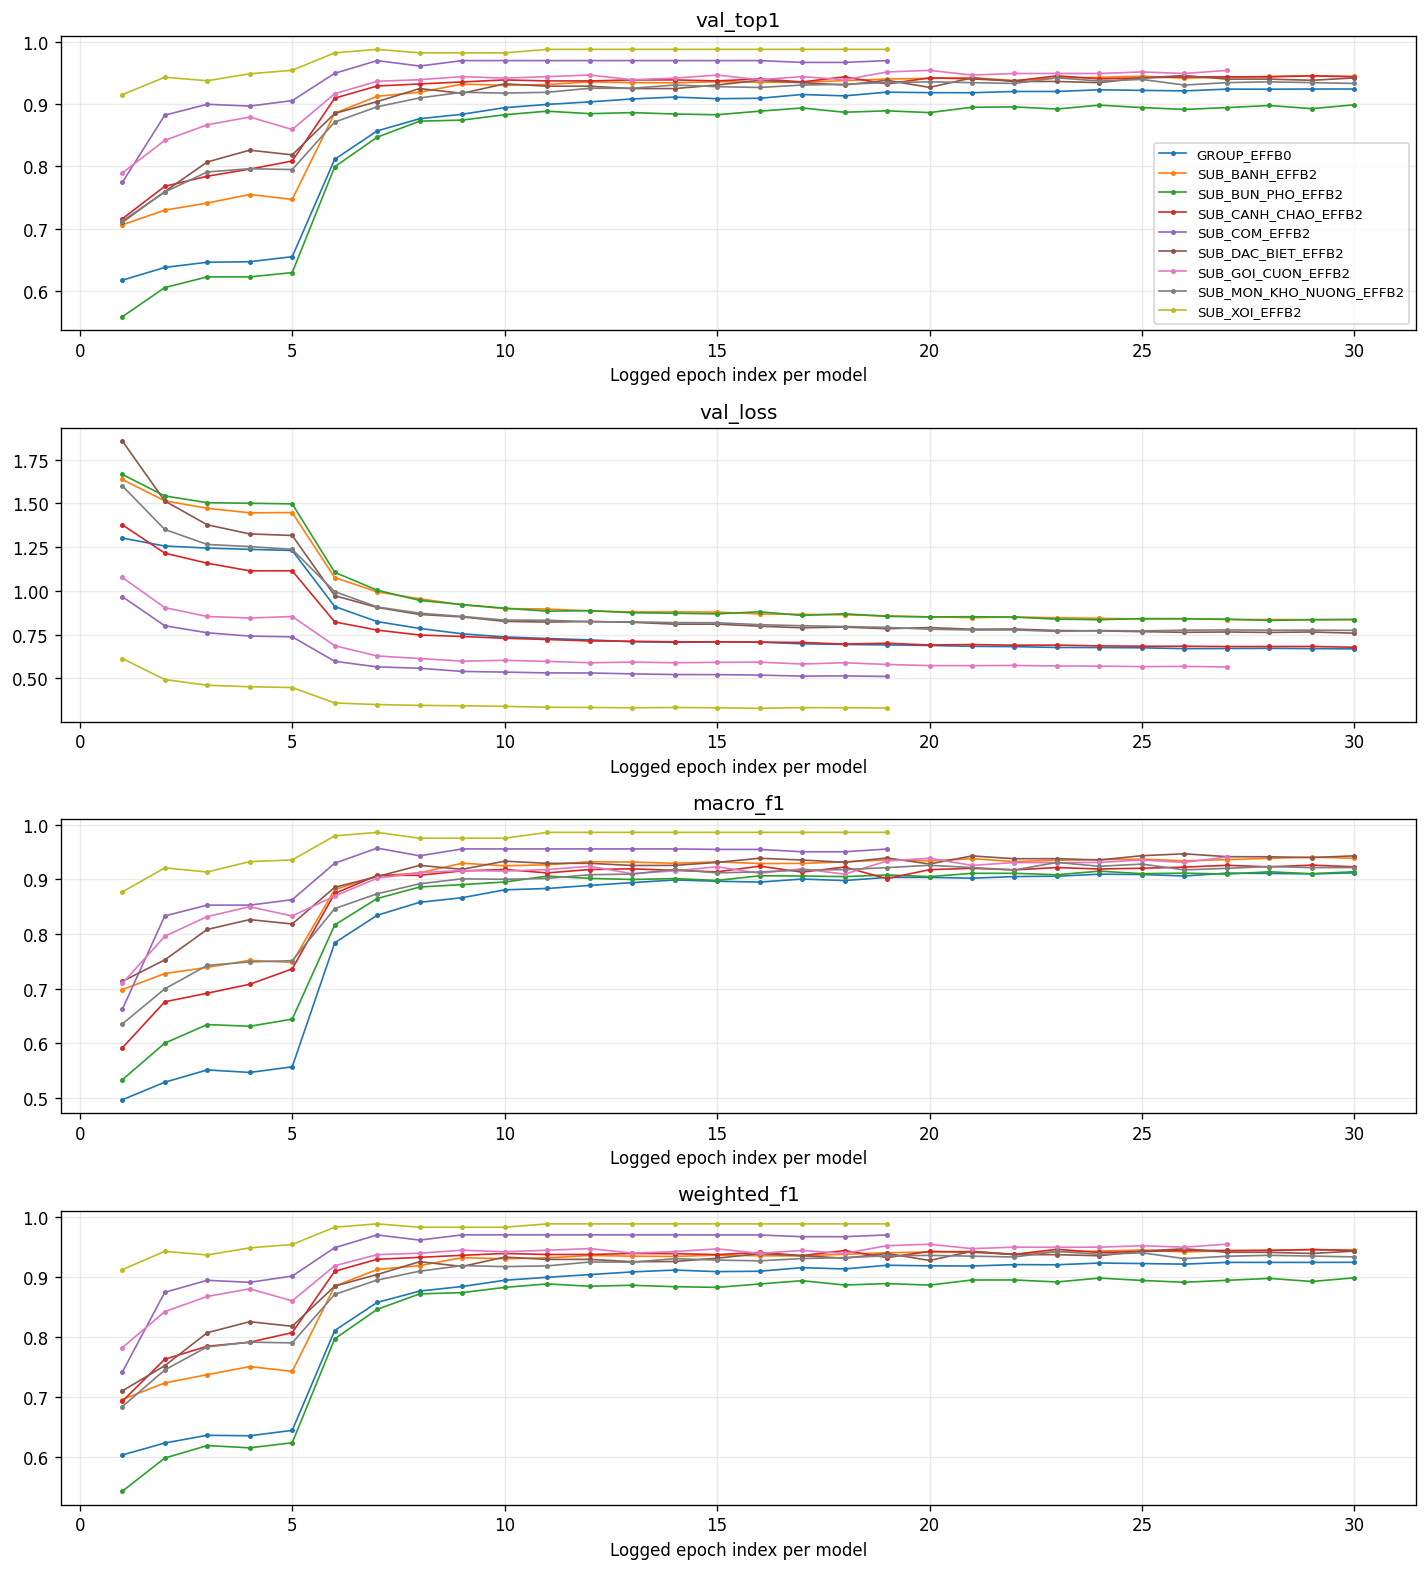

,model_name,logged_epochs,best_val_top1,best_val_top1_phase,best_val_top1_epoch,best_macro_f1,best_macro_f1_phase,best_macro_f1_epoch,best_weighted_f1,best_weighted_f1_phase,best_weighted_f1_epoch
0,SUB_XOI_EFFB2,19,0.988764,P2-top3,2,0.986349,P2-top3,2,0.988760,P2-top3,2
1,SUB_COM_EFFB2,19,0.970674,P2-top3,2,0.957496,P2-top3,2,0.970426,P2-top3,4
2,SUB_DAC_BIET_EFFB2,30,0.946565,P3-full,11,0.947053,P3-full,11,0.947270,P3-full,11
3,SUB_GOI_CUON_EFFB2,27,0.954887,P3-full,5,0.941224,P3-full,12,0.954989,P3-full,12
4,SUB_BANH_EFFB2,30,0.946247,P3-full,14,0.941063,P3-full,14,0.945893,P3-full,14
5,SUB_MON_KHO_NUONG_EFFB2,30,0.942931,P3-full,8,0.931203,P3-full,8,0.943018,P3-full,8
6,SUB_CANH_CHAO_EFFB2,30,0.946078,P3-full,8,0.926297,P3-full,14,0.946341,P3-full,8
7,SUB_BUN_PHO_EFFB2,30,0.899483,P3-full,15,0.915274,P3-full,9,0.898807,P3-full,15
8,GROUP_EFFB0,30,0.924827,P3-full,14,0.912171,P3-full,15,0.924663,P3-full,15


In [19]:
if not epoch_df.empty:
    display(Markdown('## Training Curves'))
    curve_metrics = [c for c in ['val_top1', 'val_loss', 'macro_f1', 'weighted_f1'] if c in epoch_df.columns]
    fig, axes = plt.subplots(len(curve_metrics), 1, figsize=(12, max(4, 3.3 * len(curve_metrics))), sharex=False)
    if len(curve_metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, curve_metrics):
        for model_name, g in epoch_df.groupby('model_name'):
            x = np.arange(1, len(g) + 1)
            ax.plot(x, g[metric].values, marker='o', markersize=2, linewidth=1, label=model_name)
        ax.set_title(metric)
        ax.set_xlabel('Logged epoch index per model')
        ax.grid(alpha=0.25)
    axes[0].legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

    best_rows = []
    for model_name, g in epoch_df.groupby('model_name'):
        row = {'model_name': model_name, 'logged_epochs': len(g)}
        for metric in ['val_top1', 'macro_f1', 'weighted_f1']:
            if metric in g.columns:
                idx = g[metric].idxmax()
                row[f'best_{metric}'] = g.loc[idx, metric]
                row[f'best_{metric}_phase'] = g.loc[idx, 'phase'] if 'phase' in g.columns else None
                row[f'best_{metric}_epoch'] = g.loc[idx, 'epoch'] if 'epoch' in g.columns else None
        best_rows.append(row)
    display(pd.DataFrame(best_rows).sort_values('best_macro_f1', ascending=False).reset_index(drop=True))

Change MODEL_TO_VIEW to another model_name, then rerun this cell.
Available: ['GROUP_EFFB0', 'SUB_BANH_EFFB2', 'SUB_BUN_PHO_EFFB2', 'SUB_COM_EFFB2', 'SUB_MON_KHO_NUONG_EFFB2', 'SUB_CANH_CHAO_EFFB2', 'SUB_XOI_EFFB2', 'SUB_GOI_CUON_EFFB2', 'SUB_DAC_BIET_EFFB2']


## Diagnostics: `SUB_XOI_EFFB2`

,value
model_name,SUB_XOI_EFFB2
split,test
loss,0.340742
accuracy,0.99435
balanced_accuracy,0.988506
mcc,0.98896
macro_precision,0.997151
macro_recall,0.988506
macro_f1,0.992721
weighted_precision,0.994399


### Classification Report

,precision,recall,f1-score,support
xoi-nep-than,1.000000,0.965517,0.982456,29.00000
macro avg,0.997151,0.988506,0.992721,177.00000
weighted avg,0.994399,0.994350,0.994313,177.00000
accuracy,0.994350,0.994350,0.994350,0.99435
xoi-xeo,0.991453,1.000000,0.995708,116.00000
xoi-gac,1.000000,1.000000,1.000000,32.00000


### Confusion Matrix

,xoi-gac,xoi-nep-than,xoi-xeo
xoi-gac,32,0,0
xoi-nep-than,0,28,1
xoi-xeo,0,0,116


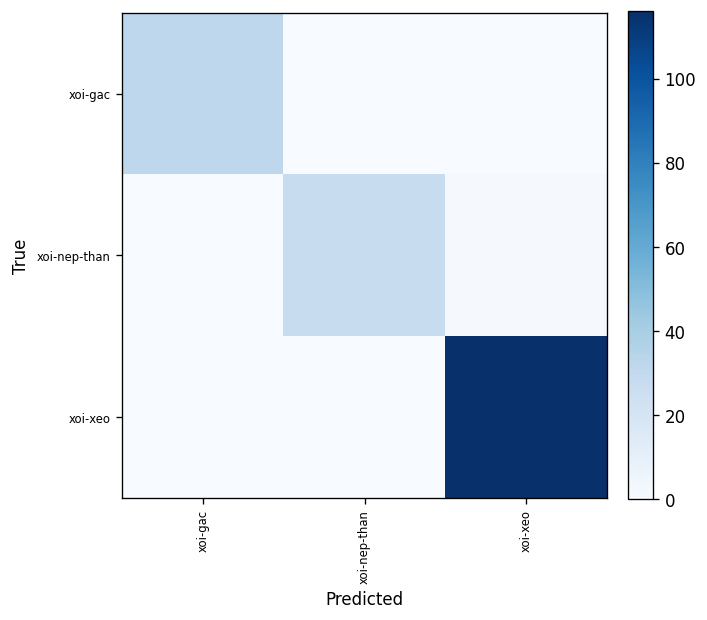

### ROC Curve

,auc
class_name,
xoi-gac,1.000000
xoi-nep-than,1.000000
micro_average,0.999824
xoi-xeo,0.999435


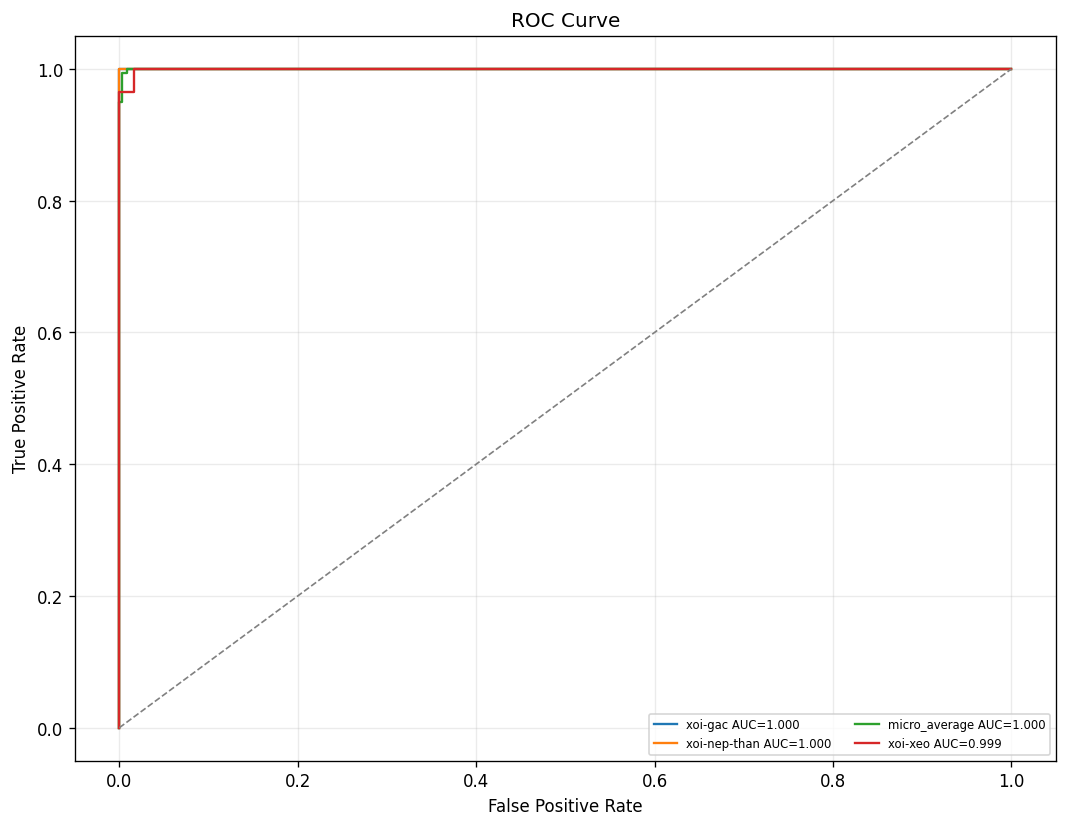

In [20]:
def localize_kaggle_path(value):
    if pd.isna(value) or value == '':
        return None
    p = Path(str(value))
    if p.exists():
        return p
    if 'confusion_matrices' in p.parts:
        return CONF_DIR / p.name
    return OUTPUT_DIR / p.name

def plot_confusion_matrix_csv(path, max_labels=40):
    cm_df = pd.read_csv(path, index_col=0)
    display(cm_df)
    plot_df = cm_df.copy()
    if len(plot_df) > max_labels:
        totals = plot_df.sum(axis=1).sort_values(ascending=False).head(max_labels).index
        plot_df = plot_df.loc[totals, totals]
        print(f'Showing top {max_labels} labels by support for readability.')
    fig_size = max(6, min(18, 0.38 * len(plot_df)))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(plot_df.values, cmap='Blues')
    ax.set_xticks(range(len(plot_df.columns)))
    ax.set_xticklabels(plot_df.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(plot_df.index)))
    ax.set_yticklabels(plot_df.index, fontsize=7)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_roc_csv(path, max_classes=18):
    roc_df = pd.read_csv(path)
    display(roc_df.groupby('class_name')['auc'].max().sort_values(ascending=False).to_frame('auc').head(30))
    auc_order = roc_df.groupby('class_name')['auc'].max().sort_values(ascending=False)
    keep = list(auc_order.head(max_classes).index)
    if 'micro_average' in auc_order.index and 'micro_average' not in keep:
        keep = ['micro_average'] + keep[:max_classes - 1]
    fig, ax = plt.subplots(figsize=(9, 7))
    for class_name in keep:
        g = roc_df[roc_df['class_name'] == class_name]
        ax.plot(g['fpr'], g['tpr'], linewidth=1.4, label=f'{class_name} AUC={g["auc"].max():.3f}')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend(loc='lower right', fontsize=7, ncol=2)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

def show_model_artifacts(model_name=None):
    if test_df.empty:
        print('test_metrics_summary.csv is empty or missing.')
        return
    if model_name is None:
        model_name = test_df.sort_values('macro_f1', ascending=False).iloc[0]['model_name']
    row = test_df[test_df['model_name'] == model_name]
    if row.empty:
        print('Unknown model. Available models:')
        print(test_df['model_name'].tolist())
        return
    row = row.iloc[0]
    display(Markdown(f'## Diagnostics: `{model_name}`'))
    display(row.to_frame('value'))

    report_path = localize_kaggle_path(row.get('classification_report_csv'))
    if report_path and report_path.exists():
        display(Markdown('### Classification Report'))
        report_df = pd.read_csv(report_path, index_col=0)
        display(report_df.sort_values('f1-score').head(25))

    cm_path = localize_kaggle_path(row.get('confusion_matrix_csv'))
    if cm_path and cm_path.exists():
        display(Markdown('### Confusion Matrix'))
        plot_confusion_matrix_csv(cm_path)

    roc_path = localize_kaggle_path(row.get('roc_curve_csv'))
    if roc_path and roc_path.exists():
        display(Markdown('### ROC Curve'))
        plot_roc_csv(roc_path)

MODEL_TO_VIEW = test_df.sort_values('macro_f1', ascending=False).iloc[0]['model_name'] if not test_df.empty else None
print('Change MODEL_TO_VIEW to another model_name, then rerun this cell.')
print('Available:', test_df['model_name'].tolist() if not test_df.empty else [])
show_model_artifacts(MODEL_TO_VIEW)

## Weakest Classes Across Reports

,model_name,class_name,precision,recall,f1-score,support
54,SUB_CANH_CHAO_EFFB2,ca-ri-ga,0.896552,0.722222,0.800000,36.0
53,SUB_CANH_CHAO_EFFB2,bo-kho,0.727273,0.888889,0.800000,27.0
94,SUB_MON_KHO_NUONG_EFFB2,bo-kho,0.785714,0.814815,0.800000,27.0
93,SUB_GOI_CUON_EFFB2,nem-nuong-nha-trang,0.787879,0.838710,0.812500,31.0
105,SUB_MON_KHO_NUONG_EFFB2,kho-quet,0.764706,0.866667,0.812500,30.0
96,SUB_MON_KHO_NUONG_EFFB2,bo-luc-lac,0.743590,0.935484,0.828571,31.0
89,SUB_GOI_CUON_EFFB2,cha-lui,0.870968,0.794118,0.830769,34.0
39,SUB_BUN_PHO_EFFB2,banh-canh,0.896774,0.789773,0.839879,176.0
76,SUB_DAC_BIET_EFFB2,khau-nhuc,0.840000,0.840000,0.840000,25.0
107,SUB_MON_KHO_NUONG_EFFB2,luon-xao-xa-ot,0.888889,0.800000,0.842105,30.0


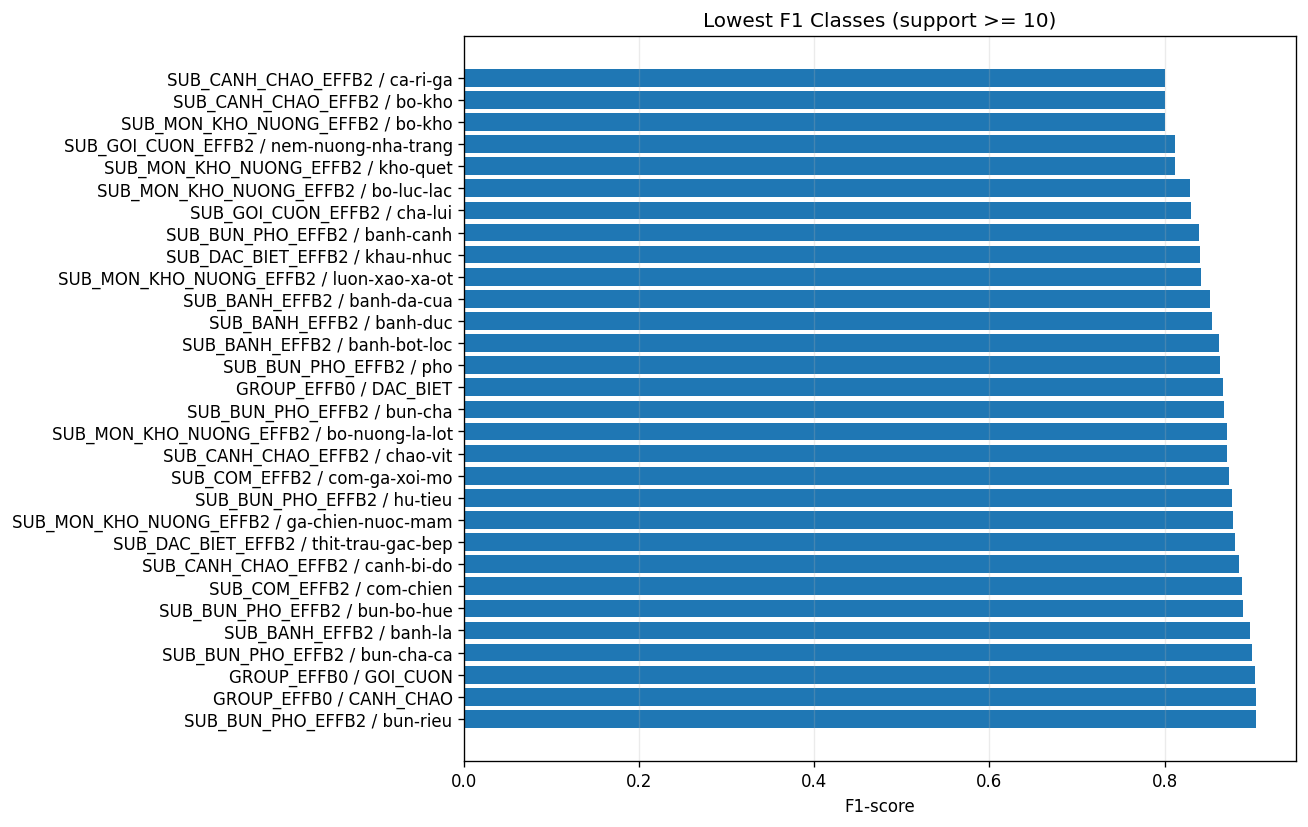

In [21]:
display(Markdown('## Weakest Classes Across Reports'))
report_rows = []
for report_path in sorted(CONF_DIR.glob('*_classification_report.csv')):
    model_name = report_path.name.replace('_classification_report.csv', '')
    df = pd.read_csv(report_path, index_col=0)
    df = df.reset_index().rename(columns={'index': 'class_name'})
    df = df[~df['class_name'].isin(['accuracy', 'macro avg', 'weighted avg'])].copy()
    df['model_name'] = model_name
    report_rows.append(df)

if report_rows:
    all_reports = pd.concat(report_rows, ignore_index=True)
    cols = ['model_name', 'class_name', 'precision', 'recall', 'f1-score', 'support']
    display(all_reports[cols].sort_values(['f1-score', 'support'], ascending=[True, False]).head(40))

    low_support = all_reports[all_reports['support'] >= 10].sort_values('f1-score').head(30)
    fig, ax = plt.subplots(figsize=(11, 7))
    labels = low_support['model_name'] + ' / ' + low_support['class_name']
    ax.barh(labels[::-1], low_support['f1-score'][::-1])
    ax.set_xlabel('F1-score')
    ax.set_title('Lowest F1 Classes (support >= 10)')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('No classification report CSV files found.')

In [22]:
display(Markdown('## Output File Inventory'))
files = []
for p in sorted(OUTPUT_DIR.rglob('*')):
    if p.is_file():
        files.append({
            'path': str(p.relative_to(OUTPUT_DIR)),
            'suffix': p.suffix,
            'size_kb': round(p.stat().st_size / 1024, 1),
        })
inventory_df = pd.DataFrame(files)
display(inventory_df)
display(inventory_df.groupby('suffix').agg(files=('path', 'count'), total_kb=('size_kb', 'sum')).reset_index())

## Output File Inventory

,path,suffix,size_kb
0,best_group_effb0.pth,.pth,15989.7
1,best_sub_BANH_effb2.pth,.pth,30702.2
2,best_sub_BUN_PHO_effb2.pth,.pth,30610.3
3,best_sub_CANH_CHAO_effb2.pth,.pth,30594.8
4,best_sub_COM_effb2.pth,.pth,30564.0
...,...,...,...
64,sub_MON_KHO_NUONG_effb2_final.pth,.pth,30631.0
65,sub_XOI_effb2_final.pth,.pth,30548.3
66,test_metrics_summary.csv,.csv,5.4
67,test_metrics_summary.xlsx,.xlsx,6.7


,suffix,files,total_kb
0,.csv,30,5038.3
1,.log,1,0.0
2,.png,18,1936.1
3,.pth,18,521685.4
4,.xlsx,2,47.6
